In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv
/kaggle/input/notebooks/deeepak00/pretrained/__results__.html
/kaggle/input/notebooks/deeepak00/pretrained/__huggingface_repos__.json
/kaggle/input/notebooks/deeepak00/pretrained/__notebook__.ipynb
/kaggle/input/notebooks/deeepak00/pretrained/__output__.json
/kaggle/input/notebooks/deeepak00/pretrained/custom.css
/kaggle/input/notebooks/deeepak00/pretrained/pretrained_model/fold_weights.json
/kaggle/input/notebooks/deeepak00/pretrained/pretrained_model/fold_0/config.json
/kaggle/input/notebooks/deeepak00/pretrained/pretrained_model/fold_0/training_args.bin
/kaggle/input/notebooks/deeepak00/pretrained/pretrained_model/fold_0/tokenizer.json
/kaggle/input/notebooks/deeepak00/pretrained/pretrained_model/fold_0/tokenizer_config.json
/kaggle/input/notebooks/deeepak00/pretrained/pretrained_mod

---
---
<h2 align="center">Sample Submission</h2>

---
---

In [2]:
# sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
# sample.to_csv("submission.csv", index=False)

## Imports

In [3]:
import os,sys, re, math, time
import os,gc,shutil,logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import Optional, Union
from sklearn.metrics import accuracy_score
from datasets import Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    logging as hf_logging,
)
from transformers.tokenization_utils_base import PreTrainedTokenizerBase, PaddingStrategy

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)

## Data Read

In [4]:
train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

---
---
<h2 align="center">Exploratory Data Analysis</h2>

---
---

In [5]:
train_df = train.copy()
test_df = test.copy()

In [6]:
print(train_df.shape)
print(test_df.shape)

(2000, 8)
(500, 7)


In [7]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


### MIssing Values per columns

In [8]:
for i in train_df.columns:
    print(f"{i}: {train_df[i].isnull().sum()} null values")

id: 0 null values
prompt: 0 null values
A: 0 null values
B: 0 null values
C: 0 null values
D: 0 null values
E: 0 null values
answer: 0 null values


### Analyze Target variable Distribution

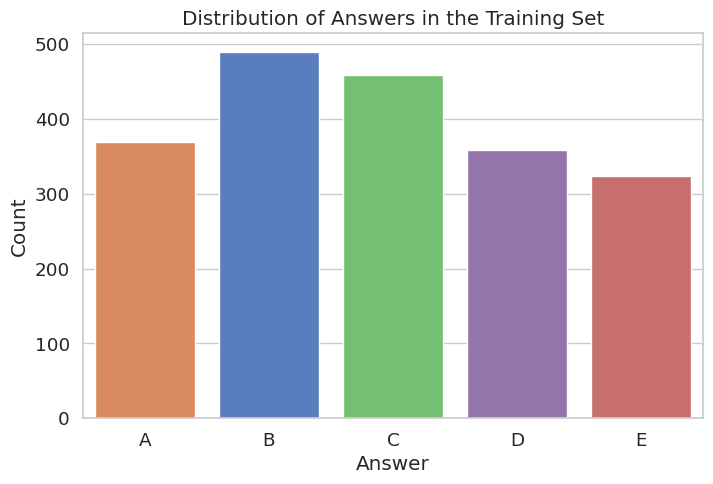

Target proportions:
answer
A    0.1845
B    0.2450
C    0.2295
D    0.1790
E    0.1620
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='answer', data=train_df, order=['A', 'B', 'C', 'D','E'], hue='answer', legend=False)
plt.title('Distribution of Answers in the Training Set')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.show()

print("Target proportions:")
print(train_df['answer'].value_counts(normalize=True).sort_index())

### Text Length Analysis

In [10]:
train_df['prompt_length'] = train_df['prompt'].apply(lambda x: len(str(x).split()))

options = ['A', 'B', 'C', 'D', 'E']
for opt in options:
    train_df[f'option_{opt}_length'] = train_df[f'{opt}'].apply(lambda x: len(str(x).split()))

train_df['avg_answer_length'] = train_df[[f'option_{opt}_length' for opt in options]].mean(axis=1)

print("Prompt length statistics:")
print(train_df['prompt_length'].describe())
print("\nAnswer length statistics:")
print(train_df['avg_answer_length'].describe())

Prompt length statistics:
count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_length, dtype: float64

Answer length statistics:
count    2000.000000
mean       26.279600
std        17.029056
min         1.000000
25%        14.600000
50%        23.000000
75%        36.800000
max        85.400000
Name: avg_answer_length, dtype: float64


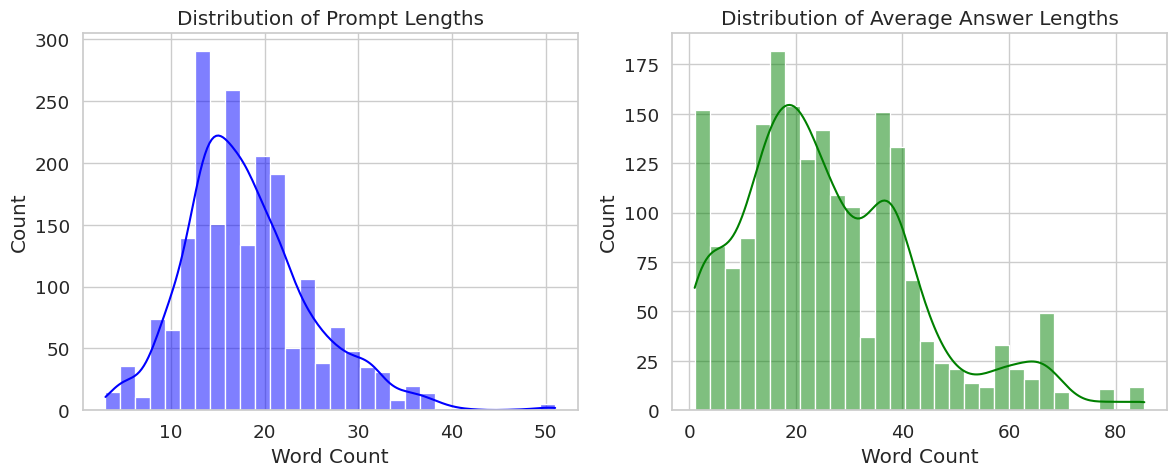

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['prompt_length'], bins=30, kde=True, color='blue')
plt.title('Distribution of Prompt Lengths')
plt.xlabel('Word Count')

plt.subplot(1, 2, 2)
sns.histplot(train_df['avg_answer_length'], bins=30, kde=True, color='green')
plt.title('Distribution of Average Answer Lengths')
plt.xlabel('Word Count')

plt.tight_layout()
plt.show()

### Word Overlaping in 'prompts' with correct and incorrect options

In [12]:
def get_overlap(row, options):
    p_words = set(str(row['prompt']).lower().split())
    o_words = set(str(row[options]).lower().split())
    return len(p_words.intersection(o_words))

overlap_correct = []
overlap_incorrect = []

for idx, row in train_df.iterrows():
    correct_option = row['answer']
    correct_overlap = get_overlap(row, correct_option)
    overlap_correct.append(correct_overlap)
    
    incorrect_options = [opt for opt in options if opt != correct_option]
    incorrect_overlaps = [get_overlap(row, opt) for opt in incorrect_options]
    overlap_incorrect.append(np.mean(incorrect_overlaps))

print("Average overlap with correct answer:", np.mean(overlap_correct))
print("Average overlap with incorrect answers:", np.mean(overlap_incorrect))

Average overlap with correct answer: 4.1095
Average overlap with incorrect answers: 4.152625


---
---
<h2 align="center">Model 1: TF-IDF + Linear Model</h2>

* This notebook implements a traditional machine learning pipeline for text classification using TF-IDF feature extraction and a Logistic Regression classifier. It includes text preprocessing, exploratory data analysis, feature engineering, model training, and submission generation.

---
---

### Data Preprocessing

In [13]:
# OPTIONS = ['A', 'B', 'C', 'D', 'E']

# def expand_df(df, is_train=True):
#     rows = []
#     for _, row in tqdm(df.iterrows(), total=len(df)):
#         for option in OPTIONS:
#             sample = {
#                 'id': row['id'],
#                 'prompt': row['prompt'],
#                 'option': row[option],
#                 'option_label': option
#             }
#             if is_train:
#                 sample['target'] = int(option == row['answer'])
#             rows.append(sample)
#     return pd.DataFrame(rows)

In [14]:
# train_expanded = expand_df(train, is_train=True)
# test_expanded = expand_df(test, is_train=False)

# print(train_expanded.shape)
# print(test_expanded.shape)

# train_expanded.head()

In [15]:
# train_expanded['text'] = (train_expanded['prompt'].astype(str)+ ' [SEP] '+ train_expanded['option'].astype(str))

# test_expanded['text'] = (test_expanded['prompt'].astype(str)+ ' [SEP] '+ test_expanded['option'].astype(str))

### Metrics

In [16]:
# def apk(actual, predicted, k=3):
#     if len(predicted) > k:
#         predicted = predicted[:k]
#     score = 0.0
#     for i, p in enumerate(predicted):
#         if p == actual:
#             score = 1.0 / (i + 1)
#             break
#     return score


# def mapk(actuals, predictions, k=3):
#     return np.mean([apk(a, p, k)for a, p in zip(actuals, predictions)])

### TF-IDF Vectorization

In [17]:
# vectorizer = TfidfVectorizer(
#     max_features=200000,
#     ngram_range=(1,3),
#     lowercase=True,
#     strip_accents="unicode",
#     sublinear_tf=True,
#     min_df=2,
#     max_df=0.95
# )



# X = vectorizer.fit_transform(train_expanded['text'])
# y = train_expanded['target']

# print(X.shape)

### Cross Validation

In [18]:
# from sklearn.model_selection import GroupKFold
# from sklearn.svm import LinearSVC
# N_SPLITS = 5

# gkf = GroupKFold(n_splits=N_SPLITS)
# groups = train_expanded['id']
# oof_probs = np.zeros(len(train_expanded))
# fold_scores = []

# for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
#     print('=' * 50)
#     print(f'FOLD {fold + 1}')

#     X_train = X[train_idx]
#     y_train = y.iloc[train_idx]

#     X_val = X[val_idx]
#     y_val = y.iloc[val_idx]

#     model = LogisticRegression(
#         C=5.0,
#         max_iter=5000,
#         solver="saga",
#         class_weight="balanced",
#         n_jobs=-1
#     )

#     model.fit(X_train, y_train)
#     val_probs = model.predict_proba(X_val)[:, 1]
#     oof_probs[val_idx] = val_probs
#     val_df = train_expanded.iloc[val_idx].copy()
#     val_df['prob'] = val_probs
    
#     actuals = []
#     predictions = []

#     for question_id, group in val_df.groupby('id'):
#         group = group.sort_values('prob',ascending=False)
#         pred_labels = (group['option_label'].head(3).tolist())
#         actual_label = (group[group['target'] == 1]['option_label'].iloc[0])

#         actuals.append(actual_label)
#         predictions.append(pred_labels)

#     fold_map3 = mapk(actuals, predictions)
#     fold_scores.append(fold_map3)
#     print(f'Fold MAP@3: {fold_map3:.5f}')

# print('\nFINAL CV MAP@3:', np.mean(fold_scores))

### Training

In [19]:
# X_train_full = vectorizer.fit_transform(train_expanded['text'])
# y_train_full = train_expanded['target']
# X_test = vectorizer.transform(test_expanded['text'])

# final_model = LogisticRegression(
#     C=5,
#     max_iter=5000,
#     class_weight='balanced',
#     n_jobs=-1
# )

# final_model.fit(X_train_full, y_train_full)
# test_probs = final_model.predict_proba(X_test)[:, 1]
# test_expanded['prob'] = test_probs

### Submission

In [20]:
# submission_rows = []

# for question_id, group in test_expanded.groupby('id'):
#     group = group.sort_values('prob',ascending=False)
#     top3 = (group['option_label'].head(3).tolist())
#     prediction = ' '.join(top3)
#     submission_rows.append({
#         'ID': question_id,
#         'Prediction': prediction
#     })

# submission = pd.DataFrame(submission_rows)
# submission.head()

In [21]:
# submission.to_csv('submission.csv',index=False)
# print('submission.csv saved')

---
---

<h2 align='center'>Model 2: GRU-based Text Classifier (Scratch Model)</h2>


* This notebook implements a GRU-based neural network for multiple-choice text classification using PyTorch. It includes text preprocessing, vocabulary construction, embedding initialization, model training, evaluation, and inference.

---
---

### SEED & GPU SETUP

In [22]:
# np.random.seed(42)
# torch.manual_seed(42)

# if torch.cuda.is_available():
#     DEVICE  = torch.device('cuda')
#     torch.cuda.manual_seed_all(42)
#     torch.backends.cudnn.benchmark = True
#     torch.backends.cuda.matmul.allow_tf32 = True
#     torch.backends.cudnn.allow_tf32 = True
#     print(f"GPU detected: {torch.cuda.get_device_name(0)}")
# else:
#     DEVICE  = torch.device('cpu')
#     print("No GPU detected — running on CPU.")

# OPTIONS   = ['A', 'B', 'C', 'D', 'E']
# LABEL2IDX = {opt: idx for idx, opt in enumerate(OPTIONS)}
# IDX2LABEL = {idx: opt for idx, opt in enumerate(OPTIONS)}

### LOAD DATA

In [23]:
# DATA_PATH = '/kaggle/input/competitions/smart-mcq-solver-challenge/'

# train_df = pd.read_csv(f"{DATA_PATH}train.csv")
# test_df  = pd.read_csv(f"{DATA_PATH}test.csv")

# train_df['answer'] = train_df['answer'].map(LABEL2IDX)


### TOKENIZER FROM SCRATCH (BPE)

* BPE (Byte Pair Encoding) tokenizer is a subword tokenizer. Instead of treating each word as a single token or each character as a token, it breaks words into frequently occurring pieces (subwords).

In [24]:
# class BpeTokenizerScratch:
#     def __init__(self, max_vocab: int = 20000):
#         from tokenizers import Tokenizer as HFTokenizer
#         from tokenizers.models import BPE
#         from tokenizers.pre_tokenizers import Whitespace
        
#         self.tokenizer = HFTokenizer(BPE(unk_token="[UNK]"))
#         self.tokenizer.pre_tokenizer = Whitespace()
#         self.max_vocab = max_vocab
#         self.size = 4

#     def build(self, texts):
#         from tokenizers.trainers import BpeTrainer
#         trainer = BpeTrainer(
#             vocab_size=self.max_vocab,
#             special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]"]
#         )
#         self.tokenizer.train_from_iterator(texts, trainer)
#         self.size = self.tokenizer.get_vocab_size()

#     def encode_pair(self, prompt: str, option: str, max_len: int = 128):
#         tp = self.tokenizer.encode(str(prompt)).ids
#         to = self.tokenizer.encode(str(option)).ids
        
#         total = max_len - 3
#         if len(tp) + len(to) > total:
#             keep_o = min(48, len(to))
#             tp = tp[:total - keep_o]
#             to = to[:total - len(tp)]

#         ids = [2] + tp + [3] + to + [3]
#         tids = [0] * (len(tp) + 2) + [1] * (len(to) + 1)
#         mask = [1] * len(ids)

#         pad = max_len - len(ids)
#         if pad > 0:
#             ids += [0] * pad
#             tids += [0] * pad
#             mask += [0] * pad

#         return ids, tids, mask

# def texts_from(df):
#     return [str(v) for col in ['prompt'] + OPTIONS for v in df[col].astype(str).tolist()]


### PRECOMPUTE

In [25]:
# def precompute(df, tok, max_len, has_labels=True):
#     n = len(df)
#     ids_arr  = np.zeros((n, 5, max_len), dtype=np.int64)
#     tids_arr = np.zeros((n, 5, max_len), dtype=np.int64)
#     mask_arr = np.zeros((n, 5, max_len), dtype=np.int64)

#     prompts = df['prompt'].astype(str).tolist()
#     opts = [df[o].astype(str).tolist() for o in OPTIONS]

#     for i in range(n):
#         p = prompts[i]
#         for j in range(5):
#             ids, tids, mask = tok.encode_pair(p, opts[j][i], max_len)
#             ids_arr[i, j] = ids
#             tids_arr[i, j] = tids
#             mask_arr[i, j] = mask

#     labels = df['answer'].values.astype(np.int64) if has_labels else None
#     return ids_arr, tids_arr, mask_arr, labels

# class MCQTensorDataset(Dataset):
#     def __init__(self, ids, tids, mask, labels=None):
#         self.ids = ids
#         self.tids = tids
#         self.mask = mask
#         self.labels = labels

#     def __len__(self):
#         return len(self.ids)

#     def __getitem__(self, i):
#         item = {
#             'input_ids': torch.from_numpy(self.ids[i]),
#             'token_type_ids': torch.from_numpy(self.tids[i]),
#             'attention_mask': torch.from_numpy(self.mask[i]),
#         }
#         if self.labels is not None:
#             item['labels'] = torch.tensor(self.labels[i])
#         return item

### MODEL

In [26]:
# class AttentionPooling(nn.Module):
#     def __init__(self, dim):
#         super().__init__()
#         self.attn = nn.Sequential(
#             nn.Linear(dim, dim // 2),
#             nn.Tanh(),
#             nn.Linear(dim // 2, 1)
#         )
        
#     def forward(self, x, mask):
#         scores = self.attn(x).squeeze(-1)
#         fill_value = torch.finfo(scores.dtype).min   # was: -1e9
#         scores = scores.masked_fill(mask == 0, fill_value)
#         weights = torch.softmax(scores, dim=1).unsqueeze(-1)
#         return (x * weights).sum(dim=1)


# class EncoderBlock(nn.Module):
#     def __init__(self, vocab_size, d_model=256, conv_ch=256, hidden=256, drop=0.2):
#         super().__init__()
#         self.emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
#         self.conv1 = nn.Conv1d(d_model, conv_ch, kernel_size=3, padding=1)
#         self.conv2 = nn.Conv1d(conv_ch, conv_ch, kernel_size=5, padding=2)
#         self.bigru = nn.GRU(conv_ch, hidden, batch_first=True, bidirectional=True)
#         self.pool = AttentionPooling(hidden * 2)
#         self.drop = nn.Dropout(drop)

#     def forward(self, ids, mask):
#         x = self.emb(ids)              # [B, T, D]
#         x = x.transpose(1, 2)          # [B, D, T]
#         x = F.relu(self.conv1(x))
#         x = F.relu(self.conv2(x))
#         x = x.transpose(1, 2)          # [B, T, C]
#         x, _ = self.bigru(x)           # [B, T, 2H]
#         out = self.pool(x, mask)
#         return self.drop(out)          # [B, 2H]

# class ScratchMCQModel(nn.Module):
#     def __init__(self, vocab_size, d_model=256, conv_ch=256, hidden=256, drop=0.2):
#         super().__init__()
#         self.encoder = EncoderBlock(vocab_size, d_model, conv_ch, hidden, drop)

#         feat_dim = hidden * 2 * 4  # q, o, |q-o|, q*o
#         self.head = nn.Sequential(
#             nn.Linear(feat_dim, feat_dim // 2),
#             nn.ReLU(),
#             nn.Dropout(drop),
#             nn.Linear(feat_dim // 2, feat_dim // 4),
#             nn.ReLU(),
#             nn.Dropout(drop),
#             nn.Linear(feat_dim // 4, 1)
#         )

#         self._init()

#     def _init(self):
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_uniform_(m.weight)
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)
#             elif isinstance(m, nn.Embedding):
#                 nn.init.normal_(m.weight, 0, 0.02)
#                 if m.padding_idx is not None:
#                     with torch.no_grad():
#                         m.weight[m.padding_idx].fill_(0.0)

#     def forward(self, input_ids, token_type_ids, attention_mask):
#         B, N, T = input_ids.shape
        
#         ids = input_ids.reshape(B * N, T)      # Encode each option separately
#         mask = attention_mask.reshape(B * N, T)
#         q_repr = self.encoder(ids, mask)   # sequence-level joint repr
#         o_repr = q_repr

#         q_repr = q_repr.view(B, N, -1)
#         o_repr = o_repr.view(B, N, -1)

#         fused = torch.cat([q_repr,o_repr,torch.abs(q_repr - o_repr),q_repr * o_repr], dim=-1)

#         logits = self.head(fused).squeeze(-1)
#         return logits

        

### METRICS

In [27]:
# def softmax_np(x):
#     e = np.exp(x - x.max(1, keepdims=True))
#     return e / e.sum(1, keepdims=True)

# def map3(y_true, probs):
#     scores = []
#     for yt, yp in zip(y_true, probs):
#         top3 = np.argsort(yp)[::-1][:3]
#         s, h = 0., 0
#         for i, p in enumerate(top3):
#             if p == yt:
#                 h += 1
#                 s += h / (i + 1)
#         scores.append(s)
#     return np.mean(scores)

# def warmup_cosine(step, warmup_steps, total_steps):
#     if step < warmup_steps:
#         return step / max(1, warmup_steps)
#     progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
#     return 0.5 * (1 + math.cos(math.pi * progress))


### CONFIG

In [28]:
# CFG = {
#     'folds': 5,
#     'epochs': 8,
#     'bs': 24,
#     'lr': 2.5e-4,
#     'wd': 0.01,
#     'd_model': 256,
#     'conv_ch': 256,
#     'hidden': 256,
#     'max_len': 128,
#     'drop': 0.2,
#     'patience': 3,
#     'label_smoothing': 0.08,
#     'warmup_frac': 0.1,
#     'max_vocab': 30000
# }

### TRAINING

In [29]:
# skf = StratifiedKFold(CFG['folds'], shuffle=True, random_state=42)
# y = train_df['answer'].values

# oof = np.zeros((len(train_df), 5))
# test_p = np.zeros((len(test_df), 5))

# for fold, (tri, vli) in enumerate(skf.split(train_df, y)):
#     print(f"\n========== FOLD {fold+1}/{CFG['folds']} ==========")

#     tok = BpeTokenizerScratch(max_vocab=CFG['max_vocab'])
#     tok.build(texts_from(train_df.iloc[tri]))
#     print("Tokenizer size:", tok.size)

#     tr_ids, tr_tids, tr_mask, tr_lbl = precompute(train_df.iloc[tri], tok, CFG['max_len'], has_labels=True)
#     vl_ids, vl_tids, vl_mask, vl_lbl = precompute(train_df.iloc[vli], tok, CFG['max_len'], has_labels=True)
#     te_ids, te_tids, te_mask, _      = precompute(test_df, tok, CFG['max_len'], has_labels=False)

#     tr_ld = DataLoader(MCQTensorDataset(tr_ids, tr_tids, tr_mask, tr_lbl),
#                        batch_size=CFG['bs'], shuffle=True, num_workers=0, pin_memory=USE_AMP)
#     vl_ld = DataLoader(MCQTensorDataset(vl_ids, vl_tids, vl_mask, vl_lbl),
#                        batch_size=CFG['bs'], shuffle=False, num_workers=0, pin_memory=USE_AMP)
#     te_ld = DataLoader(MCQTensorDataset(te_ids, te_tids, te_mask),
#                        batch_size=CFG['bs'], shuffle=False, num_workers=0, pin_memory=USE_AMP)

#     model = ScratchMCQModel(
#         vocab_size=tok.size,
#         d_model=CFG['d_model'],
#         conv_ch=CFG['conv_ch'],
#         hidden=CFG['hidden'],
#         drop=CFG['drop']
#     ).to(DEVICE)

#     opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['wd'])
#     scaler = torch.amp.GradScaler(device='cuda', enabled=USE_AMP)

#     total_steps = CFG['epochs'] * len(tr_ld)
#     warmup_steps = int(CFG['warmup_frac'] * total_steps)
#     sched = torch.optim.lr_scheduler.LambdaLR(
#         opt, lr_lambda=lambda s: warmup_cosine(s, warmup_steps, total_steps)
#     )

#     best, best_state, wait = 0.0, None, 0

#     for ep in range(CFG['epochs']):
#         model.train()
#         tl = 0.0

#         for b in tr_ld:
#             ids = b['input_ids'].to(DEVICE)
#             tids = b['token_type_ids'].to(DEVICE)
#             mask = b['attention_mask'].to(DEVICE)
#             lbl = b['labels'].to(DEVICE)

#             opt.zero_grad(set_to_none=True)
#             with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
#                 logits = model(ids, tids, mask)
#                 loss = F.cross_entropy(logits, lbl, label_smoothing=CFG['label_smoothing'])

#             scaler.scale(loss).backward()
#             scaler.unscale_(opt)
#             nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#             scaler.step(opt)
#             scaler.update()
#             sched.step()

#             tl += loss.item()

#         # validation
#         model.eval()
#         vlog = []
#         vlbl = []
#         with torch.no_grad():
#             for b in vl_ld:
#                 ids = b['input_ids'].to(DEVICE)
#                 tids = b['token_type_ids'].to(DEVICE)
#                 mask = b['attention_mask'].to(DEVICE)
#                 lbl = b['labels'].to(DEVICE)
#                 with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
#                     logits = model(ids, tids, mask)
#                 vlog.append(logits.cpu().numpy())
#                 vlbl.append(lbl.cpu().numpy())

#         vlog = np.vstack(vlog)
#         vlbl = np.concatenate(vlbl)
#         vm3 = map3(vlbl, softmax_np(vlog))
#         vacc = (vlog.argmax(1) == vlbl).mean()
#         print(f"Ep{ep+1:02d} | loss={tl/len(tr_ld):.4f} | acc={vacc:.4f} | map3={vm3:.4f}")

#         if vm3 > best:
#             best = vm3
#             best_state = {k: v.clone() for k, v in model.state_dict().items()}
#             wait = 0
#         else:
#             wait += 1
#             if wait >= CFG['patience']:
#                 print("Early stopping.")
#                 break

#     model.load_state_dict(best_state)
#     model.eval()

#     # OOF
#     vpred = []
#     with torch.no_grad():
#         for b in vl_ld:
#             ids = b['input_ids'].to(DEVICE)
#             tids = b['token_type_ids'].to(DEVICE)
#             mask = b['attention_mask'].to(DEVICE)
#             with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
#                 logits = model(ids, tids, mask)
#             vpred.append(logits.cpu().numpy())
#     oof[vli] = np.vstack(vpred)

#     # TEST
#     tpred = []
#     with torch.no_grad():
#         for b in te_ld:
#             ids = b['input_ids'].to(DEVICE)
#             tids = b['token_type_ids'].to(DEVICE)
#             mask = b['attention_mask'].to(DEVICE)
#             with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
#                 logits = model(ids, tids, mask)
#             tpred.append(logits.cpu().numpy())
#     test_p += np.vstack(tpred) / CFG['folds']

#     del model, opt, scaler, tr_ld, vl_ld, te_ld
#     torch.cuda.empty_cache()

### SUBMISSION

In [30]:
# oof_probs = softmax_np(oof)
# print("OOF MAP@3:", map3(y, oof_probs))

# test_probs = softmax_np(test_p)
# preds = [' '.join([IDX2LABEL[i] for i in np.argsort(p)[::-1][:3]]) for p in test_probs]

# sub = pd.DataFrame({
#     'ID': test_df['id'] if 'id' in test_df.columns else np.arange(1, len(test_df)+1),
#     'Prediction': preds
# })
# sub.to_csv('submission.csv', index=False)
# print(sub.head())

---
---

<h2 align='center'>Model 3: RoBERTa-Large (Pretrained model)</h2>

*  This notebook fine-tunes a RoBERTa-Large model for multiple-choice text classification using the Hugging Face Transformers library. It includes Byte-Level BPE tokenization, stratified cross-validation, model training, evaluation, and test-time inference

---
---

### SILENCE NOISY (HARMLESS) WARNINGS

In [31]:
# hf_logging.set_verbosity_error()
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

### DEVICE & SETUP

In [32]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
# print("DEVICE:", device, "| bf16 supported:", use_bf16)


# model_name = "roberta-large"
# FOLDS = 4
# MAX_LEN = 320     
# SEED = 42

### LOAD DATA

In [33]:
# train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
# test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

# label_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
# inv_map = {0: "A", 1: "B", 2: "C", 3: "D", 4: "E"}
# train_df["label"] = train_df["answer"].map(label_map)

# OPTION_COLS = ["A", "B", "C", "D", "E"]

### TOKENIZER & PREPROCESSING

In [34]:
# tokenizer = AutoTokenizer.from_pretrained(model_name)

# def preprocess_function(examples, option_order=OPTION_COLS):
#     first_sentences = [[context] * 5 for context in examples["prompt"]]
#     second_sentences = []
#     for i in range(len(examples["prompt"])):
#         options = [str(examples[col][i]) for col in option_order]
#         second_sentences.append(options)

#     first_sentences = sum(first_sentences, [])
#     second_sentences = sum(second_sentences, [])

#     tokenized_examples = tokenizer(
#         first_sentences, second_sentences, truncation=True, max_length=MAX_LEN,
#     )

#     features = {k: [v[i : i + 5] for i in range(0, len(v), 5)] for k, v in tokenized_examples.items()}
#     return features

# print("Preparing test data (standard option order)...")
# test_ds = Dataset.from_pandas(test_df)
# test_ds_mapped = test_ds.map(preprocess_function, batched=True,
#                               remove_columns=[c for c in test_ds.column_names if c != 'id'])

# REVERSED_COLS = OPTION_COLS[::-1]
# print("Preparing test data (reversed option order, for TTA)...")
# test_ds_rev_mapped = test_ds.map(
#     lambda ex: preprocess_function(ex, option_order=REVERSED_COLS),
#     batched=True, remove_columns=[c for c in test_ds.column_names if c != 'id']
# )

### CUSTOM DATA COLLATOR

In [35]:
# @dataclass
# class DataCollatorForMultipleChoice:
#     tokenizer: PreTrainedTokenizerBase
#     padding: Union[bool, str, PaddingStrategy] = True
#     max_length: Optional[int] = None
#     pad_to_multiple_of: Optional[int] = None

#     def __call__(self, features):
#         label_name = "label" if "label" in features[0].keys() else "labels"
#         labels = [feature.pop(label_name) for feature in features] if label_name in features[0].keys() else None
#         batch_size = len(features)
#         num_choices = len(features[0]["input_ids"])

#         flattened_features = [[{k: v[i] for k, v in feature.items() if k != 'id'} for i in range(num_choices)] for feature in features]
#         flattened_features = sum(flattened_features, [])

#         batch = self.tokenizer.pad(
#             flattened_features, padding=self.padding, max_length=self.max_length, pad_to_multiple_of=self.pad_to_multiple_of, return_tensors="pt",
#         )
#         batch = {k: v.view(batch_size, num_choices, -1) for k, v in batch.items()}
#         if labels is not None:
#             batch["labels"] = torch.tensor(labels, dtype=torch.int64)
#         return batch

### METRIC: MAP@3 (matches the top-3 submission format) 

In [36]:
# def map_at_3(labels, logits):
#     top3 = np.argsort(-logits, axis=1)[:, :3]
#     score = 0.0
#     for i, label in enumerate(labels):
#         if label == top3[i, 0]:
#             score += 1.0
#         elif label == top3[i, 1]:
#             score += 1.0 / 2
#         elif label == top3[i, 2]:
#             score += 1.0 / 3
#     return score / len(labels)

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=1)
#     return {
#         "accuracy": accuracy_score(labels, preds),
#         "map3": map_at_3(labels, logits),
#     }

### K-FOLD TRAINING LOOP

In [37]:
# skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
 
# all_test_preds = []       
# all_test_preds_rev = []   
# fold_weights = []       
 
# for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df["label"])):
#     fold_dir = f"./roberta_fold_{fold}"
#     print(f"\n{'='*20} FOLD {fold + 1}/{FOLDS} {'='*20}")
 
#     train_data = train_df.iloc[train_idx].reset_index(drop=True)
#     val_data = train_df.iloc[val_idx].reset_index(drop=True)
 
#     train_ds = Dataset.from_pandas(train_data)
#     val_ds = Dataset.from_pandas(val_data)
 
#     train_ds = train_ds.map(preprocess_function, batched=True, remove_columns=train_ds.column_names)
#     val_ds = val_ds.map(preprocess_function, batched=True, remove_columns=val_ds.column_names)
 
#     train_ds = train_ds.add_column("label", train_data["label"].tolist())
#     val_ds = val_ds.add_column("label", val_data["label"].tolist())
 
#     model = AutoModelForMultipleChoice.from_pretrained(model_name).to(device)
 
#     training_args = TrainingArguments(
#         output_dir=fold_dir,
#         eval_strategy="epoch",
#         save_strategy="epoch",
 
#         save_only_model=True,
#         save_total_limit=1,
 
#         learning_rate=1e-5,             
#         weight_decay=0.01,
#         num_train_epochs=4,             
#         per_device_train_batch_size=2,
#         per_device_eval_batch_size=4,
#         gradient_accumulation_steps=8,
#         gradient_checkpointing=True,
#         warmup_ratio=0.15,              
#         max_grad_norm=1.0,
#         lr_scheduler_type="cosine",
#         label_smoothing_factor=0.05,    
#         logging_steps=20,
#         bf16=use_bf16,                  
#         fp16=not use_bf16,
#         load_best_model_at_end=True,
#         metric_for_best_model="map3",   
#         greater_is_better=True,
#         report_to="none",
#         seed=SEED,
#     )
 
#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_ds,
#         eval_dataset=val_ds,
#         data_collator=DataCollatorForMultipleChoice(tokenizer=tokenizer),
#         compute_metrics=compute_metrics,
#         callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
#     )
 
#     trainer.train()
 
#     val_metrics = trainer.evaluate()
#     fold_map3 = val_metrics["eval_map3"]
#     fold_weights.append(fold_map3)
#     print(f"Fold {fold + 1} val MAP@3: {fold_map3:.4f} | val accuracy: {val_metrics['eval_accuracy']:.4f}")
 
#     print(f"Inferencing test data for fold {fold + 1} (standard order)...")
#     fold_preds = trainer.predict(test_ds_mapped).predictions
#     all_test_preds.append(fold_preds)
 
#     print(f"Inferencing test data for fold {fold + 1} (reversed order, TTA)...")
#     fold_preds_rev = trainer.predict(test_ds_rev_mapped).predictions
#     # un-reverse columns so index 0 is always option A again
#     fold_preds_rev = fold_preds_rev[:, ::-1]
#     all_test_preds_rev.append(fold_preds_rev)
 
#     print(f"Cleaning up disk and memory for fold {fold + 1}...")
#     del model, trainer
#     torch.cuda.empty_cache()
#     gc.collect()
#     if os.path.exists(fold_dir):
#         shutil.rmtree(fold_dir)

### ENSEMBLE & FINAL OUTPUT 

In [38]:
# print("\n" + "="*40)
# print("Fold MAP@3 scores:", [f"{w:.4f}" for w in fold_weights])

# fold_weights = np.array(fold_weights)
# fold_weights = fold_weights / fold_weights.sum()  

# # softmax each fold's logits before combining (both orderings), then weighted-average probabilities
# std_probs = [torch.softmax(torch.tensor(p), dim=1).numpy() for p in all_test_preds]
# rev_probs = [torch.softmax(torch.tensor(p.copy()), dim=1).numpy() for p in all_test_preds_rev]

# # average the two TTA views per fold first, then weight across folds
# per_fold_probs = [(s + r) / 2 for s, r in zip(std_probs, rev_probs)]
# final_probs = np.tensordot(fold_weights, np.stack(per_fold_probs), axes=(0, 0))

# final = []
# for i, p in enumerate(final_probs):
#     top3_indices = np.argsort(p)[::-1][:3]
#     top3_letters = [inv_map[idx] for idx in top3_indices]
#     final.append({
#         "id": test_ds["id"][i],
#         "prediction": " ".join(top3_letters)
#     })

# submission = pd.DataFrame(final)
# submission.to_csv("/kaggle/working/submission.csv", index=False)
# print(submission.head())
# print("Ensemble submission ready.")

---
---

<h2 align='center'>Inferences from GitHub scripts</h2>

---
---

### 1. Reading Secret Key (Wandb Api key and Github PAT)

In [39]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("github_access")
secret_value_1 = user_secrets.get_secret("WANDB_API_KEY")

### 2. Cloning Github Repo

In [40]:
!git clone https://{secret_value_0}@github.com/deeepak00/smart-mcq-solver-dlgenai-2026.git

Cloning into 'smart-mcq-solver-dlgenai-2026'...
remote: Enumerating objects: 279, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 279 (delta 21), reused 29 (delta 10), pack-reused 227 (from 1)
Receiving objects: 100% (279/279), 313.27 KiB | 10.80 MiB/s, done.
Resolving deltas: 100% (122/122), done.


### TF-IDF + Linear Model Inference

In [41]:
# !python -m smart-mcq-solver-dlgenai-2026.src.tfidf.inference --artifacts-dir /kaggle/input/notebooks/deeepak00/tfidf/smart-mcq-solver-dlgenai-2026/artifacts/

### GRU Based Scratch Model Inference

In [42]:
# !python smart-mcq-solver-dlgenai-2026/src/scratch/inference.py \
#                         --data_path /kaggle/input/competitions/smart-mcq-solver-challenge \
#                         --artifacts_dir /kaggle/input/notebooks/deeepak00/scratch/artifacts \
#                         --output_path /kaggle/working/submission.csv

### Pretrained Model Inference

In [43]:
!pip install -q transformers datasets scikit-learn
%cd smart-mcq-solver-dlgenai-2026

/kaggle/working/smart-mcq-solver-dlgenai-2026


In [44]:
!python -m src.pretrained.inference \
    --test_csv /kaggle/input/competitions/smart-mcq-solver-challenge/test.csv \
    --saved_models_dir /kaggle/input/notebooks/deeepak00/pretrained/pretrained_model\
    --output_csv /kaggle/working/submission.csv

DEVICE: cuda | bf16 supported: True
Map: 100%|███████████████████████████| 500/500 [00:00<00:00, 1175.51 examples/s]
Inferencing with fold_0 ...
Loading weights: 100%|█| 393/393 [00:01<00:00, 320.57it/s, Materializing param=r
Inferencing with fold_1 ...
Loading weights: 100%|█| 393/393 [00:00<00:00, 423.97it/s, Materializing param=r
Inferencing with fold_2 ...
Loading weights: 100%|█| 393/393 [00:00<00:00, 454.87it/s, Materializing param=r
Inferencing with fold_3 ...
Loading weights: 100%|█| 393/393 [00:01<00:00, 386.81it/s, Materializing param=r
Inferencing with fold_4 ...
Loading weights: 100%|█| 393/393 [00:00<00:00, 435.92it/s, Materializing param=r

Fold MAP@3 scores: ['0.9304', '0.7867', '0.9550', '0.9113', '0.9354']
   id prediction
0   1      A D B
1   2      B E D
2   3      B E C
3   4      E C D
4   5      C D A
Ensemble submission ready -> /kaggle/working/submission.csv
